In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv(
    "../data/processed/oil_well_clean.csv",
    index_col="date",
    parse_dates=True
)
df.head()

,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
date,,,,,,,,
2013-01-01,49.0,70.0,13055.0,21.0,29.0,24.0,1819.0,214.0
2013-01-02,49.0,70.0,13055.0,21.0,29.0,24.0,1836.0,214.0
2013-01-03,49.0,70.0,13055.0,21.0,29.0,24.0,1788.0,214.0
2013-01-04,49.0,70.0,13055.0,21.0,29.0,24.0,1789.0,214.0
2013-01-05,44.0,70.0,11768.0,26.0,36.0,24.0,1825.0,214.0


In [3]:
oil = df["oil_volume"]
t = np.arange(len(oil))
q = oil.values

In [4]:
def exp_decline(t, qi, D):
    return qi * np.exp(-D * t)

params, _ = curve_fit(exp_decline, t, q, maxfev=10000)

qi, D = params

print("Initial production qi:", qi)
print("Decline rate D:", D)

Initial production qi: 38.17468224860973
Decline rate D: 0.000626389336620912


C:\Users\Admin\AppData\Local\Temp\ipykernel_19584\2441076953.py:2: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19584\2441076953.py:2: RuntimeWarning: overflow encountered in multiply
  return qi * np.exp(-D * t)


In [5]:
q_pred = exp_decline(t, qi, D)

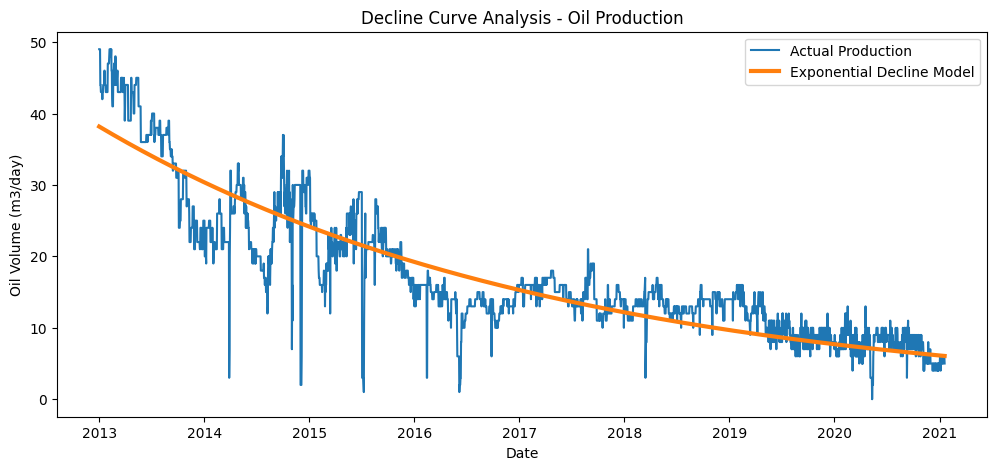

In [6]:
plt.figure(figsize=(12,5))

plt.plot(df.index, q, label="Actual Production")
plt.plot(df.index, q_pred, label="Exponential Decline Model", linewidth=3)

plt.title("Decline Curve Analysis - Oil Production")
plt.ylabel("Oil Volume (m3/day)")
plt.xlabel("Date")

plt.legend()
plt.savefig("../outputs/figures/decline_curve_analysis.png")
plt.show()

In [7]:
future_days = 365 * 2
t_future = np.arange(len(q) + future_days)
q_future = exp_decline(t_future, qi, D)

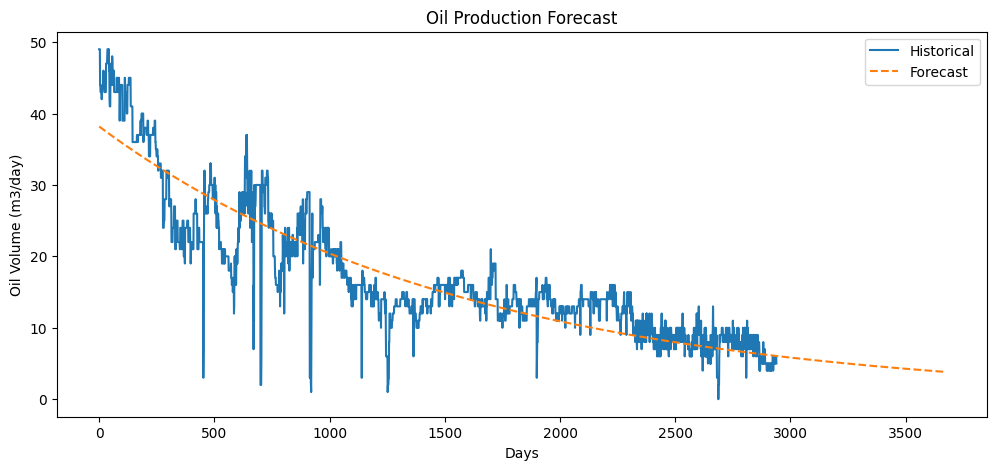

In [9]:
plt.figure(figsize=(12,5))
plt.plot(t, q, label="Historical")
plt.plot(t_future, q_future, label="Forecast", linestyle="--")
plt.title("Oil Production Forecast")
plt.ylabel("Oil Volume (m3/day)")
plt.xlabel("Days")
plt.legend()
plt.savefig("../outputs/figures/oil_production_forecast.png")
plt.show()

In [10]:
oil_smooth = oil.rolling(window=30).mean()

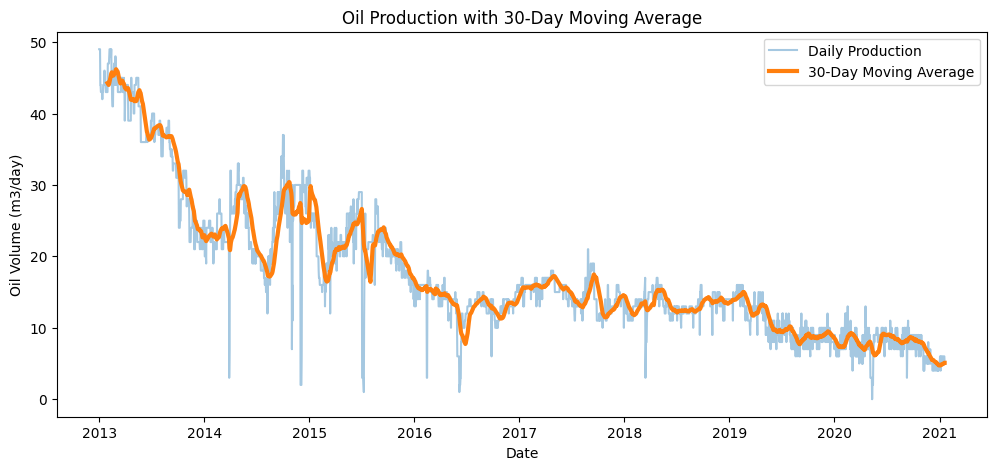

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.index, oil, alpha=0.4, label="Daily Production")
plt.plot(df.index, oil_smooth, linewidth=3, label="30-Day Moving Average")
plt.title("Oil Production with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Oil Volume (m3/day)")
plt.legend()
plt.savefig("../outputs/figures/oil_production_moving_average.png")
plt.show()

In [12]:
oil_smooth = oil_smooth.dropna()

In [13]:
t = np.arange(len(oil_smooth))
q = oil_smooth.values

In [14]:
def exp_decline(t, qi, D):
    return qi * np.exp(-D * t)

params, _ = curve_fit(exp_decline, t, q, maxfev=10000)

qi, D = params

print("Initial production qi:", qi)
print("Decline rate D:", D)

Initial production qi: 37.5016731696443
Decline rate D: 0.0006190129071600292


C:\Users\Admin\AppData\Local\Temp\ipykernel_19584\2441076953.py:2: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19584\2441076953.py:2: RuntimeWarning: overflow encountered in multiply
  return qi * np.exp(-D * t)


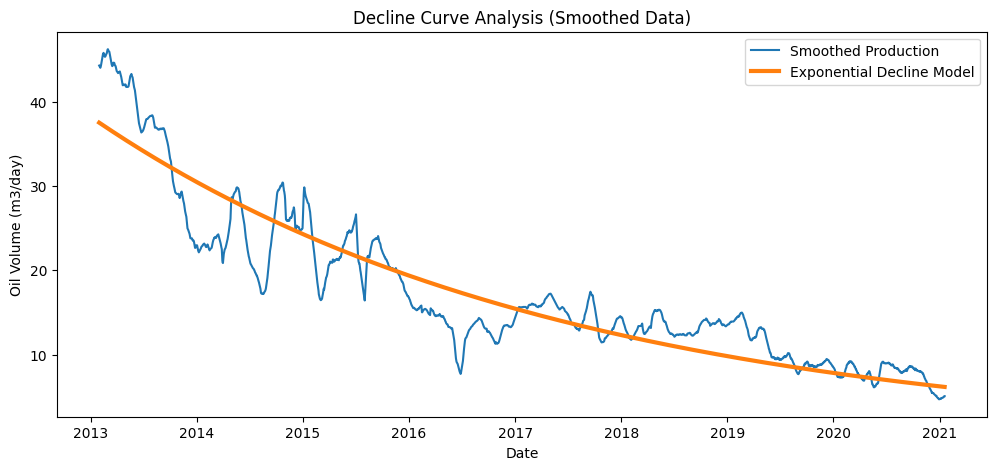

In [15]:
q_pred = exp_decline(t, qi, D)

plt.figure(figsize=(12,5))
plt.plot(oil_smooth.index, q, label="Smoothed Production")
plt.plot(oil_smooth.index, q_pred, label="Exponential Decline Model", linewidth=3)
plt.title("Decline Curve Analysis (Smoothed Data)")
plt.xlabel("Date")
plt.ylabel("Oil Volume (m3/day)")
plt.legend()
plt.savefig("../outputs/figures/decline_curve_smoothed.png")
plt.show()